# Classificador Naive Bayes: Do zero a Biblioteca

>**Objetivo:** Compreender a matemática e o funcionamento do algoritmo Naive Bayes através de uma implementação manual em Python puro e, em seguida, aplicar a solução utilizando a biblioteca `scikit-learn`.

## 1. Introdução e Teoria
O **Naive Bayes** é um algoritmo de aprendizado de máquina supervisionado baseado no **Teorema de Bayes**. Ele é amplamente utilizado para problemas de classificação, como detecção de spam e sistemas de recomendação.

### A Regra de Bayes
A formula matemática fundamental do algoritmo é:

$$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$

Onde:
* **$P(A|B)$ (Posterior):** Probabilidade da classe $A$ ocorrer dado que a característica $B$ ocorreu.
* **$P(B|A)$ (Verossimilhança / Likelihood):** Probabilidade da carecterística $B$ ocorrer dado a classe $A$.
* **$P(A)$ (A Priori / Prior):** Probabilidade marginal da classe $A$.
* **$P(B)$ (Evidência):** Probabilidade marginal da característica $B$.

> **Por que "Ingênuo" (Naive)?**
> O algoritmo assume que todas as características (features) são **completamente independentes** entre si dado o rótulo da classe. Embora isso raramente aconteça no mundo real, o modelo costuma ter um desempenho super rápido e robusto.

> Vamos ver um classificador Naive Bayes em ação através de um exemplo simplificado de recomendação de filmes.


## Implementando o Naive Bayes do zero

In [ ]:
import numpy as np

## DATASET DE TREINO (Historico do usuario)
X_train = np.array([
    [0, 1, 1],
    [0, 0, 1],
    [0, 0, 0],
    [1, 1, 0]])

# Rotulo: 'Y' = Gostou, 'N' = Não Gostou
y_train = ['Y', 'N', 'Y', 'Y']

X_test = np.array([1, 1, 0])

Para o modelo, começando com prior, primeiro agrupamos os dados pelo o rotulo e registramos seus indices por classe.

In [ ]:
def get_label_indices(labels):
  """
  Agrupa as amostras com base em seus rótulos e retorna os índices
  @para labels: lista de rótulos
  @return: dict, {class1: [índices], class2: [índices]}
  """
  from collections import defaultdict
  label_indices = defaultdict(list)
  for index, label in enumerate(labels):
    label_indices[label].append(index)
  return label_indices


label_indices = get_label_indices(y_train)
print(f'label_indices: {label_indices}')

label_indices: defaultdict(<class 'list'>, {'Y': [0, 2, 3], 'N': [1]})


Com label_indices, calculamos a priori:

In [ ]:
def get_prior(label_indices):
  """
  Calcular a priori com base nas amostras de treinamento
  @param label_indices: índices de amostras agrupadas por classe
  @return: dicionário, com o rótulo da classe como chave e priori correspondente como valor
  """

  prior = {label: len(indices) for label, indices in label_indices.items()}

  total_count = sum(prior.values())
  for label in prior:
    prior[label] /= total_count

  return prior


prior = get_prior(label_indices)
print(f"Priori: {prior}")

Priori: {'Y': 0.75, 'N': 0.25}


 Com prior calculado, continuamos com likelihood, que é a probabilidade condicional, P(**feature|class**)

Justificativa do Smoothing (Suavização de Laplace)**:
Aplicamos o smothing para resolver o  **Problema da Probabilidade Zero**. No Naive Bayes, as probabilidades são multiplicadas. Se o modelo encontrar um feature nova (que nunca apareceu em uma classe durante o treino), a sua probabilidade condicional seria 0, o que zeraria o resultado final de toda fórmula. A suavização adiciona uma contagem pequena a todas as features, garantindo que nenhuma probabilidade seja nula e tornando o modelo mais tolerante as dados inéditos.

In [ ]:
def get_likelihood(features, label_indices, smoothing=0):
  """
  Calcula a verossimilhança com base nas amostras de treinamento
  @param features: matriz de caractéristicas
  @param label_indices: índices das amostras agrupada pela classe
  @param smooting: inteiro, parametro de suavização aditiva
  @return: dicionário, com a classe como chave, vetor de probabilidade condicioanl P(feature|class) como valor
  """
  likelihood = {}
  for label, indices in label_indices.items():
    likelihood[label] = features[indices, :].sum(axis=0) + smoothing
    total_count = len(indices)
    likelihood[label] = likelihood[label] / (total_count + 2 * smoothing)

  return likelihood


"""
Definimos o valor de smoothing aqui como 1, o que também pode ser 0 para ausência de suavização,
ou qualquer outro valor positivo, desde que seja alcançado um bom desempenho de classificação mais elevado
"""

smothing = 1
likelihood = get_likelihood(X_train, label_indices, smothing)
print(f"Likelihood: {likelihood}")

Likelihood: {'Y': array([0.4, 0.6, 0.4]), 'N': array([0.33333333, 0.33333333, 0.66666667])}


Com a priori e a verossimilhança prontas, podemos calcular o posterior para a amostras de teste/novas

In [ ]:
def get_posterior(X, prior, likelihood):
  """
  Calcula o posterior das amostras de teste, com base na priori e na verossimilhança
  @param X: amostras de teste
  @param prior: dicionário, com rótulo da classe como chave, priori correspondente
  como valor
  @param likelihood: dicionário, com rótulo da classe como chave, vetor de probabilidade
  condicional correspondente como valor
  @return: dicionário, com rótulo da classe como chave, posterior correspondente como valor
  """

  posteriors = []
  for x in X:
    # o posterior é proporcional ao prior * verossimilhança
    posterior = prior.copy()
    for label, likelihood_label in likelihood.items():
      for index, bool_value in enumerate(x):
        posterior[label] *= likelihood_label[index] if bool_value else ( 1 - likelihood_label[index])

    # normalizar para que tudo some 1
    sum_posterior = sum(posterior.values())
    for label in posterior:
      if posterior[label] == float('inf'):
        posterior[label] = 1.0
      else:
        posterior[label] /= sum_posterior
    posteriors.append(posterior.copy())

  return posteriors

Agora vamos prever a classe do nosso conjunto de teste de uma amostra usando esta função de predição

In [ ]:
posterior = get_posterior([X_test], prior, likelihood)
print(f"Posterior: {posterior}")

Posterior: [{'Y': np.float64(0.9210360075805433), 'N': np.float64(0.07896399241945673)}]


Densevolvemos com sucesso o Naive Bayes do zero e agora podemos passar para a implementação usando `scikit-learn`.

## Implementando o Naive Bayes com scikit-learn


Primeiro vamos importar a biblioteca para o nosso codigo junto com o modulo BernouliiNB

In [ ]:
from sklearn.naive_bayes import BernoulliNB

"""
vamos inicializar o modelo com um fator de suavização (específicado como alpha)
de 1.0, e prior aprendido a partir do conjunto do treinamento (específicado como
fit_prior=True no scikit-learn)
"""

clf = BernoulliNB(alpha=1.0, fit_prior=True)

# utilizando o metodo fit para treinar o classificador
clf.fit(X_train, y_train)

# vamos utilizar o metodo predict_proba para obter os resultados de probabilidade previstos
pred_prob = clf.predict_proba([X_test])
print(f'[scikit-learn] Probabilidades previstas: {pred_prob}')


[scikit-learn] Probabilidades previstas: [[0.07896399 0.92103601]]


Por fim, fazemos o seguinte para adquirir diretamente a classe prevista com o método `predict` (0.5 é o limite padrão, e se probabilidade prevista da classe Y for maior que 0.5, a classe Y é atrubuída; caso contrário, N é usada:

In [ ]:
pred = clf.predict([X_test])
print(f"[scikit-learn] Predição: {pred}")

[scikit-learn] Predição: ['Y']


Os resultados da predição usando o scikit-learn são consistentes com o que obtivemos usando a nossa própria solução. Agora que implementamos o algoritmo tanto do zero quanto usando `scikit-learn`, por que não usá-lo para resolver o problema de recomendação de filmes?

## Construindo um recomendador de filmes com Naive Bayes

Após compreendermos a matemática por trás do algoritmo com um exemplo simplificado, vamos aplicar o **Naive Bayes** em um cenário real: a construção de um **sistema de recomendação de filmes** (especificamente, um classificador de preferência).

### Sobre o Dataset: MovieLens 1M
* **Volume dos Dados:** O conjunto possui cerca de **1 milhão de avaliações** (variando de 1 a 5, com incrementos de meio ponto).
* **Escopo:** Os dados cobrem as interações de **6.040 usuários** avaliando um total de **3.706 filmes** (com última atualização em setembro de 2018).
* **Download Direto:** O arquivo compactado tem aproximadamente 1 MB e pode ser baixado diretamente pelo link do [ml-1m.zip](https://files.grouplens.org/datasets/movielens/ml-1m.zip) ou inspecionado na página de [diretório do MovieLens 1M](https://grouplens.org/datasets/movielens/1m).


### Objetivo do Experimento
O propósito desta seção é transformar o histórico de avaliações do usuário em características categóricas se um usuário **gostaria (`Y`)** ou **não gostaria (`N`)** de um filme inédito com base no comportamento de pessoas com gostos similares.


### Preparando os Dados
Importação de todos os módulos necessários e leitura do ratings.dat em um objeto pandas Dataframe objeto:

In [ ]:
import numpy as np
import pandas as pd

data_path = 'ml-1m/ratings.dat'
df = pd.read_csv(data_path, header=None, sep='::', engine='python', encoding='ISO-8859-1')

df.columns = ['user_id', 'movie_id', 'rating', 'timestamp']
print(df)

         user_id  movie_id  rating  timestamp
0              1      1193       5  978300760
1              1       661       3  978302109
2              1       914       3  978301968
3              1      3408       4  978300275
4              1      2355       5  978824291
...          ...       ...     ...        ...
1000204     6040      1091       1  956716541
1000205     6040      1094       5  956704887
1000206     6040       562       5  956704746
1000207     6040      1096       4  956715648
1000208     6040      1097       4  956715569

[1000209 rows x 4 columns]


Vamos ver quantos usuários e filmes únicos existem nesse dataset

In [ ]:
n_users = df['user_id'].nunique()
n_movies = df['movie_id'].nunique()

print(f"Número de usuários únicos: {n_users}")
print(f"Número de filmes únicos: {n_movies}")

Número de usuários únicos: 6040
Número de filmes únicos: 3706


Agora vamos construir uma matriz de 6040 (número de úsuarios) por 3706 (número de filmes) em que cada linha contém a avaliação de um usuário e cada coluna representa um filme, com a seguinte função:

In [ ]:
def load_user_rating_data(df, n_users, n_movies):
  data = np.zeros([n_users, n_movies], dtype=np.intc)
  movie_id_mapping = {}
  for user_id, movie_id, rating in zip(df['user_id'], df['movie_id'], df['rating']):
    user_id = int(user_id) - 1
    if movie_id not in movie_id_mapping:
      movie_id_mapping[movie_id] = len(movie_id_mapping)

    data[user_id, movie_id_mapping[movie_id]] = rating

  return data, movie_id_mapping


data, movie_id_mapping = load_user_rating_data(df, n_users, n_movies)

Além da matriz `data`, também registramos o mapeamento do `movie_id` para o índice da coluna. O índice da coluna vai de 0 a 3705, pois temos 3706 filmes.

Para evitar um problema de desbalanceamento de classes no conjunto de dados, é sempre recomendado analisar a distribuição dos dados. Para isso vamos fazer o seguinte:

In [ ]:
values, counts = np.unique(data, return_counts=True)


for value, count in zip(values, counts):
  print(f'Quantidade de avaliações {value} : {count}')

Quantidade de avaliações 0 : 21384031
Quantidade de avaliações 1 : 56174
Quantidade de avaliações 2 : 107557
Quantidade de avaliações 3 : 261197
Quantidade de avaliações 4 : 348971
Quantidade de avaliações 5 : 226310


A maioria das avaliações é desconhecida. Das que são conhecidas, 35% são de avaliações 4, seguidas por 26% de avaliação 3, 23% de avaliação 5, e depois 11% e 6% de avaliações 1 e 2, respectivamente.

Como a maioria das avaliações é desconhecida, para facilitar a validação da predição, o nosso filme alvo vai ser aquele com o maior número de avaliações conhecidas. A contagem de avaliações para cada filme acontece da seguinte forma:

In [ ]:
df['movie_id'].value_counts()

,count
movie_id,
2858,3428
260,2991
1196,2990
1210,2883
480,2672
...,...
872,1
2703,1
2845,1


Então o nosso filme alvo é o `ID 2858` e vamos trazer as avaliações dos outros filmes como features. Só iremos usar as linhas com avaliações disponíveis para o filme alvo para validar a qualidade da predição. O conjuntos de dados fica da seguinte maneira:

In [ ]:
target_movie_id = 2858
X_raw = np.delete(data, movie_id_mapping[target_movie_id], axis=1)
Y_raw = data[:, movie_id_mapping[target_movie_id]]

X = X_raw[Y_raw>0]
Y = Y_raw[Y_raw>0]

print(f"Formato de X: {X.shape}")
print(f"Formato de Y: {Y.shape}")

Formato de X: (3428, 3705)
Formato de Y: (3428,)


Podemos considerar filmes com avaliações maiores que 3 como sendo recomendados:

In [ ]:
rec = 3
Y [Y <= rec] = 0
Y [Y > rec] = 1

n_pos = (Y == 1).sum()
n_neg = (Y == 0).sum()

print(f"Amostras positivas: {n_pos}")
print(f"Amostras negativas: {n_neg}")

Amostras positivas: 2853
Amostras negativas: 575


Usamos a função `train_test_split` do `scikit-learn` para fazer a divisão aleatória e preservar a porcentagem de amostras de cada classe:

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(len(y_train), len(y_test))

2742 686


### Treinando um modelo Naive Bayes

Nota-se que os valores das features vão de 0 a 5, ao contrário do nosso exemplo didático que era 0 ou 1. Por isso vamos utilizar o módulo `MultinomialNB` do scikit-learn, em vez do `BernoulliNB`, pois o `MultinomialNB` consegue trabalhar tanto com características inteiras quanto com contagens fracionárias.
Importamos o módulo, inicializamos um módelo com fator de suavização de 1.0 e `prior` aprendido a partir do conjunto de treinamento, e treinamos esse modelo no conjunto de treinamento da seguinte forma:


In [ ]:
from sklearn.naive_bayes import MultinomialNB

clf = MultinomialNB(alpha=1.0, fit_prior=True)
clf.fit(X_train, y_train)

MultinomialNB()

Em seguida, usamos o modelo treinado para trazer previsões sobre o conjunto de teste. As probabilidades previstas são obtidas da seguinte forma:

In [ ]:
prediction_prob = clf.predict_proba(X_test)
prediction_prob[0:10]

array([[7.50487439e-23, 1.00000000e+00],
       [1.01806208e-01, 8.98193792e-01],
       [3.57740570e-10, 1.00000000e+00],
       [1.00000000e+00, 2.94095407e-16],
       [1.00000000e+00, 2.49760836e-25],
       [7.62630220e-01, 2.37369780e-01],
       [3.47479627e-05, 9.99965252e-01],
       [2.66075292e-11, 1.00000000e+00],
       [5.88493563e-10, 9.99999999e-01],
       [9.71326867e-09, 9.99999990e-01]])

Para cada amostra de teste, exibimos a probabilidade da classe 0, seguida da classe 1. Isso acontece da seguinte forma:

In [ ]:
prediction = clf.predict(X_test)
prediction[:10]

array([1, 1, 1, 0, 0, 0, 1, 1, 1, 1], dtype=int32)

Por fim, vamos avaliar o modelo com a acurácia de classificação, que é a proporção de predições corretas:

In [ ]:
accuracy = clf.score(X_test, y_test)
print(f'A acurácia do nosso modelo é: {accuracy * 100:.2f}%')

A acurácia do nosso modelo é: 71.57%


A acurácia do nosso modelo de classificação está em torno de 72%, o que signfica que o classificador recomenda filmes aos usuários corretamente quase 3/4 das vezes. Até agora avaliamos o seu desempenho pela acurácia de previsão. Existem outras métricas de classificação muito importantes, as quais veremos no proximo tópico.

### Avaliando o desempenho da classificação

Além da acurácia, há várias métricas que podemos usar para obter mais insights e evitar efeitos de desbalanceamento de classes. São elas:

* Matriz de confusão
* Precisão
* Recall
* F1-Score
* Área sob a curva

Uma **matriz de confusão** resume as instâncias de teste por seus valores preditos e valores verdadeiros, apresentados como uma tabela de contingência:

| Actual \ Predicted | Negative | Positive |
| :--- | :--- | :--- |
| **Negative** | TN | FP |
| **Positive** | FN | TP |

* **TN** = True Negative
* **FP** = False Positive
* **FN** = False Negative
* **TP** = True Positive


Para ilustrar isso, podemos calcular a matriz de confusão do nosso classificador Naïve Bayes. Usamos a função `confusion_matrix` do `scikit-learn` para obtê-la:

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, prediction, labels=[0,1]))

[[ 60  47]
 [148 431]]


Como podemos ver, a matriz apresenta 47 casos de falso positivo (onde o modelo interpreta erroneamente um dislike como um like para um filme), e 148 casos de falso negativo (onde falha em detectar um like para um filme). Desse jeito, a acurácia do classificador é apenas a proporção de todos os casos verdadeiros:

$$ \frac{TN + TP}{TN + TP + FP + FN} = \frac{60 + 431}{60 + 431 + 47 + 148} = 71.6\%$$

A **precisão** mede a fração de chamadas positivas que estão corretas, que são as seguintes no nosso caso:

$$ \frac{TP}{TP + FP}=\frac{431}{431 + 47}=0.90 $$

O **recall**, por outro lado, mede a fração de verdadeiros positivos que foram corretamente identificados, nesse caso:

$$ \frac{TP}{TP + FN}=\frac{431}{431 + 148}=0.74 $$

O **f1-score** inclui de forma compreensiva tanto a precisão quanto o recall e equivale a sua média harmônica:

$$ f1 = 2 ⋅ \frac{precision ⋅ recall}{precision + recall}$$

Tendemos a valorizar a f1-score acima da precisão ou recall isoladamente.

Vamos calcular essa três métricas utilizando as seguintes funções do `scikit-learn`:

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f'Precisão: {precision_score(y_test, prediction, pos_label=1)}')
print(f'Recall: {recall_score(y_test, prediction, pos_label=1)}')
print(f'f1-score: {f1_score(y_test, prediction, pos_label=1)}')

Precisão: 0.9016736401673641
Recall: 0.7443868739205527
f1-score: 0.815515610217597


Podemos encontrar essas três métricas de um jeito mais rápido, usando a função `classification_report`:

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(y_test, prediction)
print(report)

              precision    recall  f1-score   support

           0       0.29      0.56      0.38       107
           1       0.90      0.74      0.82       579

    accuracy                           0.72       686
   macro avg       0.60      0.65      0.60       686
weighted avg       0.81      0.72      0.75       686



`weighted avg` é a média ponderada de acordo com a proporção das classes.

O `classification_report` oferece uma visão abrangente de como o modelo classificador se comporta em cada classe. Por isso, ele é muito útil em classificação desbalanceada, onde uma alta acurácia pode ser obtida simplesmente classificando todas as amostras como a classe dominante, enquanto as métricas de precisão, recall e f1-score serão baixas para a classe minoritária.

Precisão, recall e f1-score também são aplicáveis a classificação multiclasse, onde podemos escolher uma classe de interesse como caso positivo e as outras classes como casos negativos.

Por fim, a **Área sob a Curva (ROC AUC)**, complementa a precisão, o recall e o f1-score de uma forma crucial: ela avalia o modelo em **todos os limiares de decisão possíveis**, e não apenas no padrão de 50%.

Enquanto as três métricas anteriores medem o sucesso de uma decisão fixa, a ROC AUC mede a capacidade do modelo de **ordenar e separar as classes**. Ela calcula a probabilidade de o classificador atribuir uma nota mais alta para um caso positivo real do que para um negativo.

Por olhar para o panorama completo, a AUC gera um válor único de 0 a 1 que é altamente estável, servindo como a métrica definitiva para comparar o desempenho geral de diferentes algoritmos.

Vamos codificar e exibir a curva ROC do nosso modelo:

In [ ]:
pos_prob = prediction_prob[:, 1]
thresholds = np.arange(0.0, 1.1, 0.05)
true_pos, false_pos = [0]*len(thresholds), [0]*len(thresholds)

for pred, y in zip(pos_prob, y_test):
  for i, threshold in enumerate(thresholds):
    if pred >= threshold:
      # se a verdade e a predição forem ambos 1
      if y == 1:
        true_pos[i] += 1
      # se a verdade for 0 e a predição for 1
      else:
        false_pos[i] += 1
    else:
      break

Agora vamos calcular as taxas de verdadeiros e falsos positivos para todas as configurações de limiar.

In [ ]:
n_pos_test = (y_test == 1).sum()
n_neg_test = (y_test == 0).sum()

true_pos_rate = [tp / n_pos_test for tp in true_pos]
false_pos_rate = [tp / n_neg_test for tp in false_pos]

Com isso, podemos calcular a curva ROC com matplot.lib

/tmp/ipykernel_589/2936102400.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


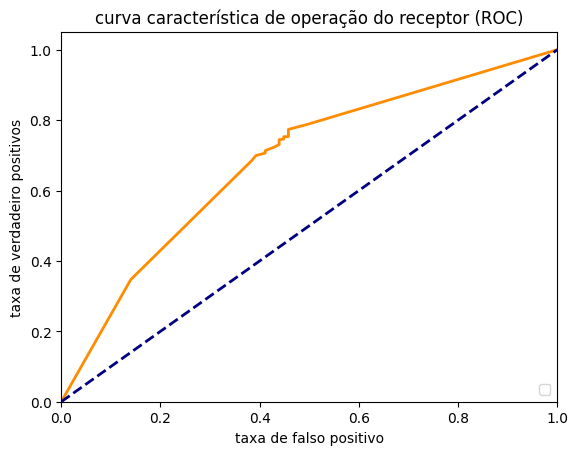

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
lw = 2
plt.plot(false_pos_rate, true_pos_rate, color='darkorange', lw=lw)

plt.plot([0,1],[0,1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('taxa de falso positivo')
plt.ylabel('taxa de verdadeiro positivos')
plt.title('curva característica de operação do receptor (ROC)')
plt.legend(loc="lower right")
plt.show()

A linha tracejada é linha de base que representa o chute aleatório, onde a taxa de verdadeiros positivos aumenta linearmente com a taxa de falsos positivos; sua AUC é 0,5. A linha sólida é o gráfico ROC do nosso modelo, e sua AUC é um pouco menor do que 1. Para saber a AUC exata do modelo, podemos usar a a função `roc_auc_score` do scikit-learn:

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, pos_prob)

np.float64(0.6857375752586637)

Não existe um número mágico para o valor de AUC para definir se um modelo classificador é bom ou não. Mas existe uma orientação geral e regra prática, com as seguintes diretrizes: modelos de classificação que atingem um AUC de `0.7` a `0.8` são considerados aceitáveis, de `0.8` a `0.9` são ótimos, e quaisquer valores acima de `0.9` são considerados excepcionais. No nosso caso, estamos usando dados de avaliações de filmes que são muito esparsos. Então, um AUC de 0.69 também é considerado aceitável.

### Ajustando o modelo com validação cruzada

A Validação Cruzada é uma técnica essencial para avaliar a capacidade do modelo Naive Bayes de generalizar para novos dados, evitando o viés de uma única divisão entre treino e teste. No método mais comum, o K-Fold, o dataset é dividido em K partes iguais; o algoritmo é treinado e testado K vezes, alternando qual parte serve de teste enquanto as outras servem de treino. A importância dessa abordagem está em eliminar o "fator sorte" na escolha dos dados de teste, fornecendo uma métrica de desempenho muito mais realista e ajudando a detectar precocemente problemas de overfitting (quando o modelo decora em vez de aprender). Com esses conceitos em mente, podemos agora começar a ajustar nosso classificador Naive Bayes, incorporando validação cruzada e a AUC das medições da curva ROC.

Usaremos o método `split()` da classe `StratifiedKFold` do scikit-learn para dividir os dados em partes de forma que a distribuição das classes seja preservada:

In [ ]:
from sklearn.model_selection import StratifiedKFold

k = 5
k_fold = StratifiedKFold(n_splits=k)

Após inicializar um gerador de 5 dobras, escolhemos explorar os seguintes valores para os seguintes parâmetros:

*   `alpha`: Isso representa o fator de suavização, o valor inicial para cada característica
*   `fit_prior`: Isso representa se deve usar a prior adaptada aos dados de treinamento

Vamos começar com as seguintes opções:



In [ ]:
smooting_factor_option = [1, 2, 3, 4, 5, 6]
fit_prior_option = [True, False]
auc_record = {}

Para cada fold gerado pelo método `split()` do objeto `k_fold`, repetimos  o processo de inicialização, treinamento e predição do classficador com uma das combinações de parâmetros mencionadas anteriormente, e registramos os AUCs resultantes:

In [ ]:
for train_indices, test_indices in k_fold.split(X, Y):
  X_train_k, X_test_k = X[train_indices], X[test_indices]
  Y_train_k, Y_test_k = Y[train_indices], Y[test_indices]
  for alpha in smooting_factor_option:
    if alpha not in auc_record:
        auc_record[alpha] = {}
    for fit_prior in fit_prior_option:
      clf = MultinomialNB(alpha=alpha, fit_prior=fit_prior)
      clf.fit (X_train_k, Y_train_k)
      prediction_prob = clf.predict_proba(X_test_k)
      pos_prob = prediction_prob[:, 1]
      auc = roc_auc_score(Y_test_k, pos_prob)
      auc_record[alpha][fit_prior] = auc + auc_record[alpha].get(fit_prior, 0.0)


Por fim, apresentamos os resultados da seguinte forma:

In [ ]:
for smoothing, smoothing_record in auc_record.items():
  for fit_prior, auc in smoothing_record.items():
    print(f'{smoothing}  {fit_prior} {auc/k:.5f}')

1  True 0.65647
1  False 0.65708
2  True 0.65795
2  False 0.65823
3  True 0.65740
3  False 0.65801
4  True 0.65808
4  False 0.65795
5  True 0.65814
5  False 0.65694
6  True 0.65663
6  False 0.65719


O conjunto (2, False) é o que resulta na melhor AUC média, de 0.65823.

Por fim, retreinamos o modelo com o melhor conjunto de hiperparâmetros(2, False) e calculamos a AUC:

In [ ]:
clf = MultinomialNB(alpha=2, fit_prior=False)
clf.fit(X_train, y_train)
pos_prob = clf.predict_proba(X_test)[:,1]
print(f"AUC com o melhor modelo: {roc_auc_score(y_test, pos_prob)}")

AUC com o melhor modelo: 0.6862056720417091


Uma AUC de 0.686 é alcançada com o modelo com ajuste fino. O ajuste de hiperparâmetros do modelo usando validação cruzada é uma das melhores maneiras de melhorar o desempenho do aprendizado e reduzir o overfitting.